<a href="https://colab.research.google.com/github/RamiroIsaJ/Aprendizaje_maquina_ML/blob/main/Taller_1_Algoritmos_Clustering_RIJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

** Taller 1 de Métodos de Aprendizaje de Máquina **
* Por: Ramiro Isa Jara
* Fecha: 28 de julio de 2026

In [ ]:
# 1. Carga del dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import copy

os.chdir('..')

data_wine = pd.read_csv('/content/drive/MyDrive/Aprendizaje_maquina_UTPL/Trabajos/winequality-redmod.csv', delimiter=',', encoding='unicode_escape')
print('Dataset loaded succesfully')

Dataset loaded succesfully


In [ ]:
# 2 (a). Analisis de las columnas del dataset
data_wine.info(verbose=True)
data_wine.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   alcohol               1599 non-null   float64
dtypes: float64(8)
memory usage: 100.1 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,14.900000


In [ ]:
# 2(b): revision de los datos
data_wine.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,alcohol
244,15.0,0.21,0.44,2.2,0.075,10.0,24.0,9.2
1598,6.0,0.31,0.47,3.6,0.067,18.0,42.0,11.0
243,15.0,0.21,0.44,2.2,0.075,10.0,24.0,9.2
610,8.8,0.24,0.54,2.5,0.083,25.0,57.0,9.2
1509,7.9,0.18,0.40,1.8,0.062,7.0,20.0,11.1
1304,7.6,0.79,0.21,2.3,0.087,21.0,68.0,9.2
1400,7.9,0.69,0.21,2.1,0.080,33.0,141.0,9.9
42,7.5,0.49,0.20,2.6,0.332,8.0,14.0,10.5
813,6.9,0.39,0.24,2.1,0.102,4.0,7.0,11.4
547,10.6,0.31,0.49,2.5,0.067,6.0,21.0,10.7


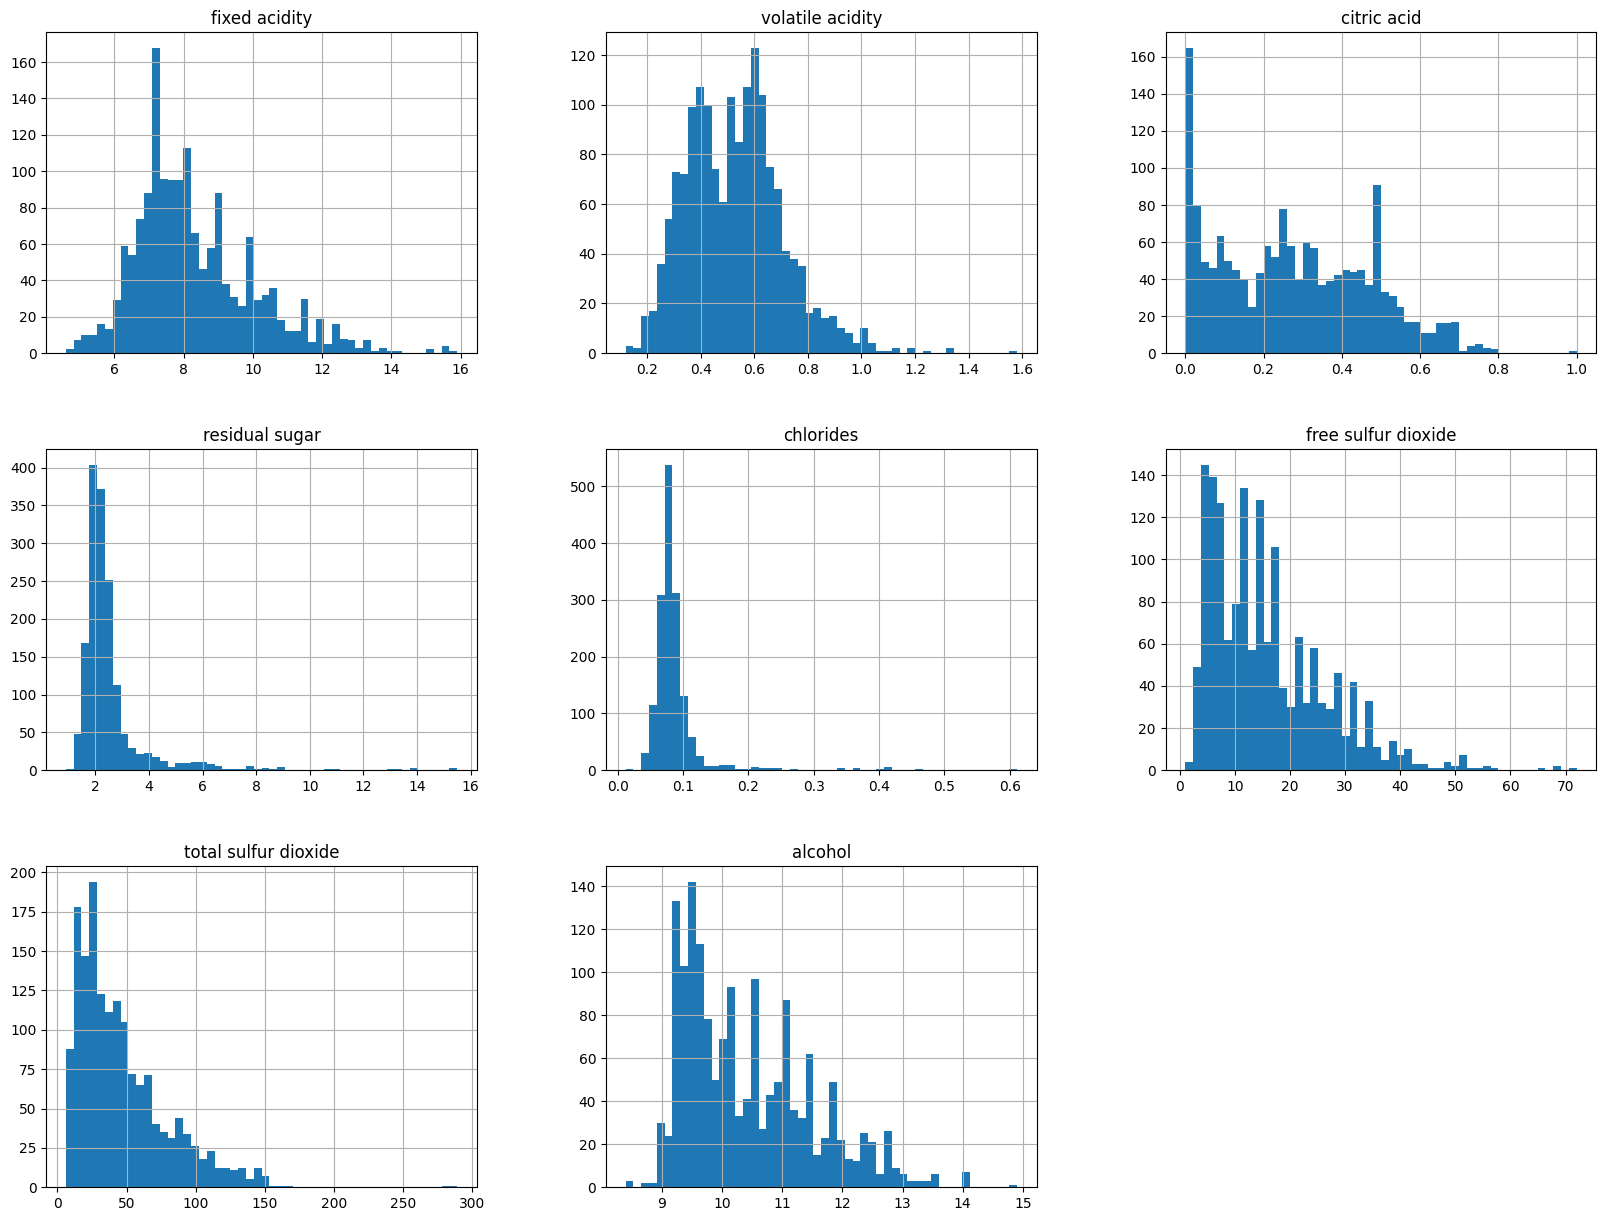

In [ ]:
# 2(c): graficas de los datos
data_wine.hist(bins=50, figsize=(20,15))
plt.show()

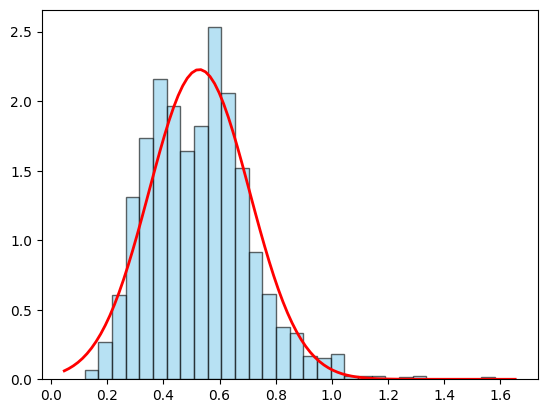

In [ ]:
import scipy.stats as stats

datos = data_wine['volatile acidity']
mu, std = datos.mean(), datos.std()
plt.hist(datos, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r-', linewidth=2, label='Aprox. Distribución Normal')
plt.show()

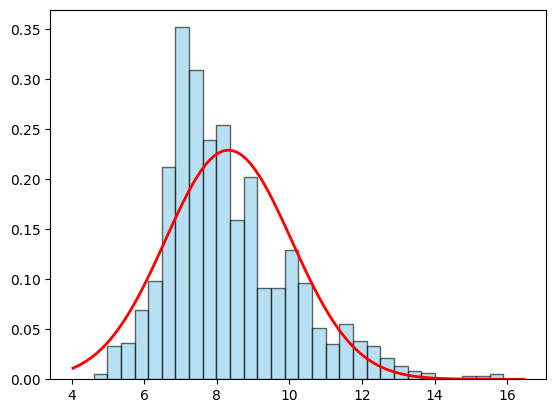

In [ ]:
datos = data_wine['fixed acidity']
mu, std = datos.mean(), datos.std()
plt.hist(datos, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r-', linewidth=2, label='Aprox. Distribución Normal')
plt.show()

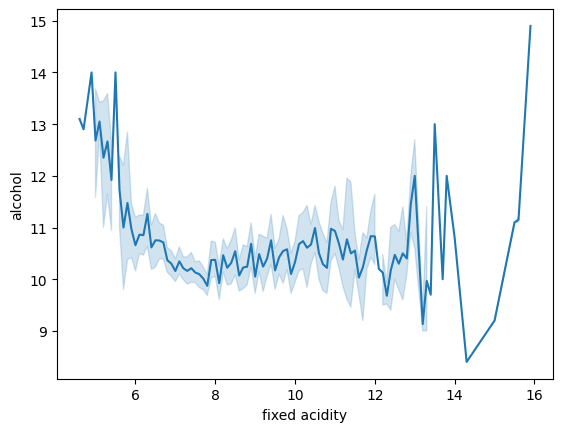

In [ ]:
sns.lineplot(x=data_wine['fixed acidity'], y=data_wine['alcohol'], data=data_wine)
plt.show()

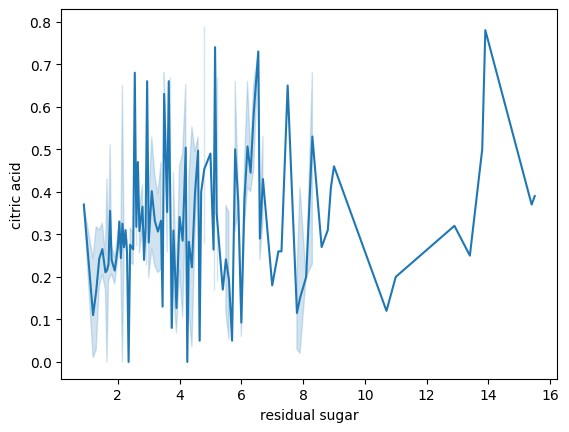

In [ ]:
sns.lineplot(x=data_wine['residual sugar'], y=data_wine['citric acid'], data=data_wine)
plt.show()

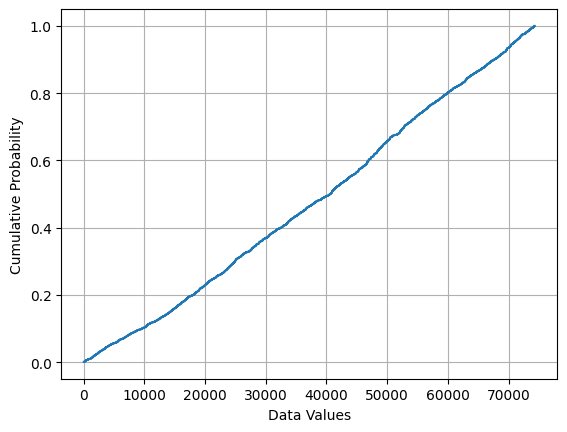

In [ ]:
datos = data_wine["total sulfur dioxide"].cumsum()
sorted_data = np.sort(datos)
y_values = np.arange(1, len(datos) + 1) / len(datos)

# Plot as a stairstep line graph
plt.step(sorted_data, y_values, where='post')
plt.grid()
plt.xlabel("Data Values")
plt.ylabel("Cumulative Probability")
plt.show()

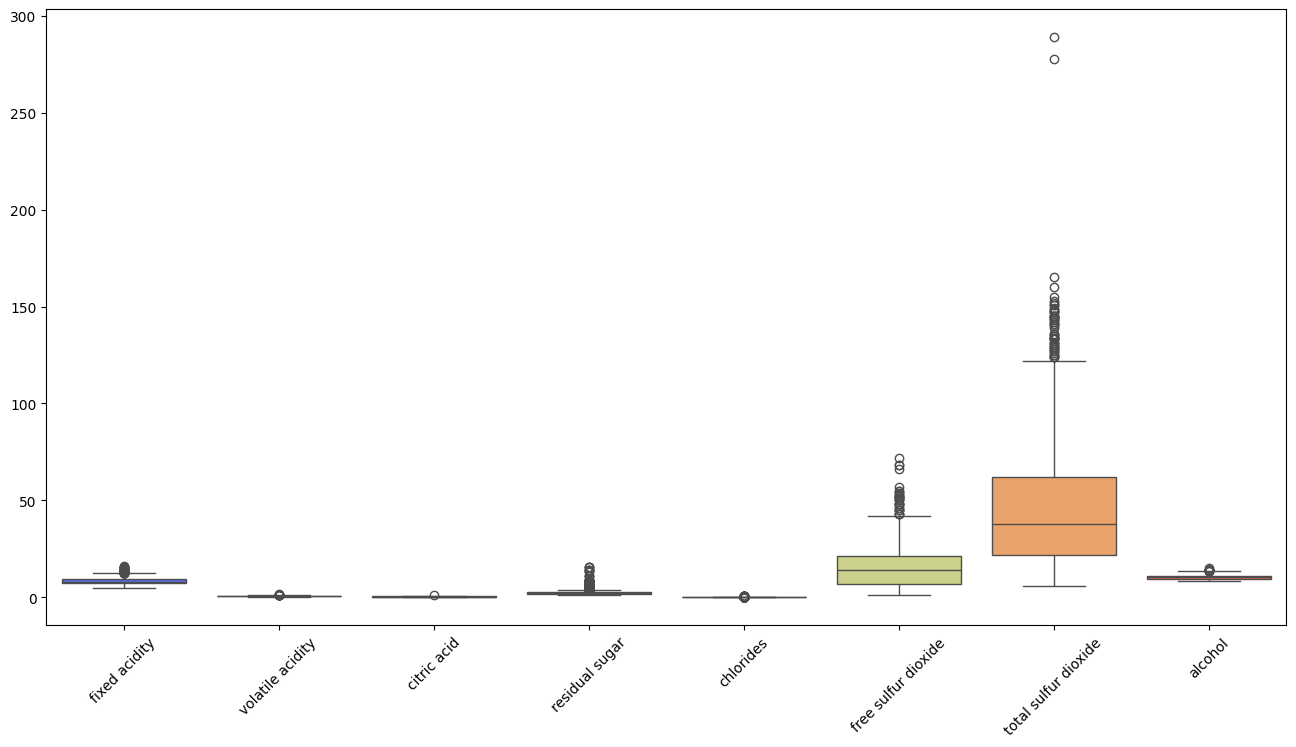

In [ ]:
plt.figure(figsize=(16,8))

sns.boxplot(data=data_wine, palette='rainbow')

plt.xticks(rotation=45)
plt.show()

<Axes: >

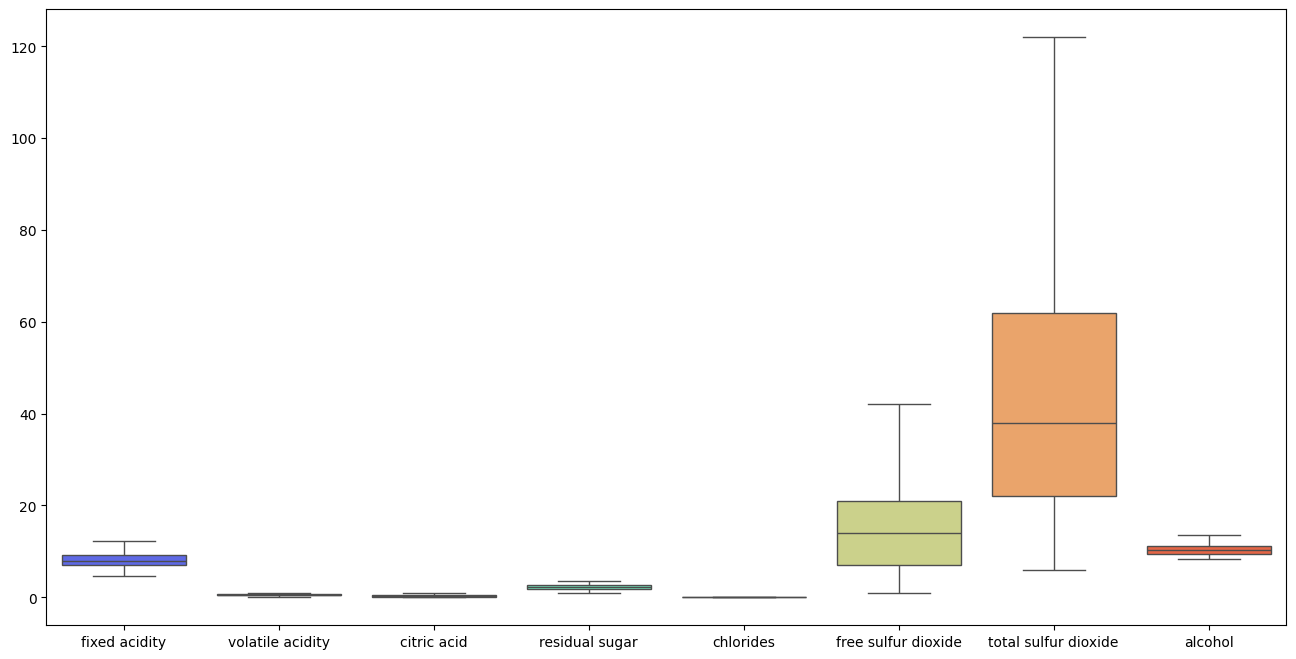

In [ ]:
# 3. Tratamiento de datos atípicos
numeric_cols = data_wine.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = data_wine[col].quantile(0.25)
    Q3 = data_wine[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data_wine[col] = data_wine[col].clip(lower, upper)

plt.figure(figsize=(16,8))
sns.boxplot(data=data_wine,palette='rainbow')

In [ ]:
# 4. Normalización de datos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_Norm_wine = scaler.fit_transform(data_wine)
data_Norm_wine = pd.DataFrame(data_Norm_wine, columns=data_wine.columns)

In [ ]:
# 5. Uso de PCA al dataset para evaluar el mejor numero de componentes
from sklearn.decomposition import PCA

pca = PCA()
data_PCA= pca.fit_transform(data_Norm_wine)
print(pca.explained_variance_ratio_)

[0.2698883  0.22614025 0.17444254 0.1290528  0.07501966 0.06186638
 0.04012769 0.02346237]


Text(0, 0.5, 'Cumulative explained variables')

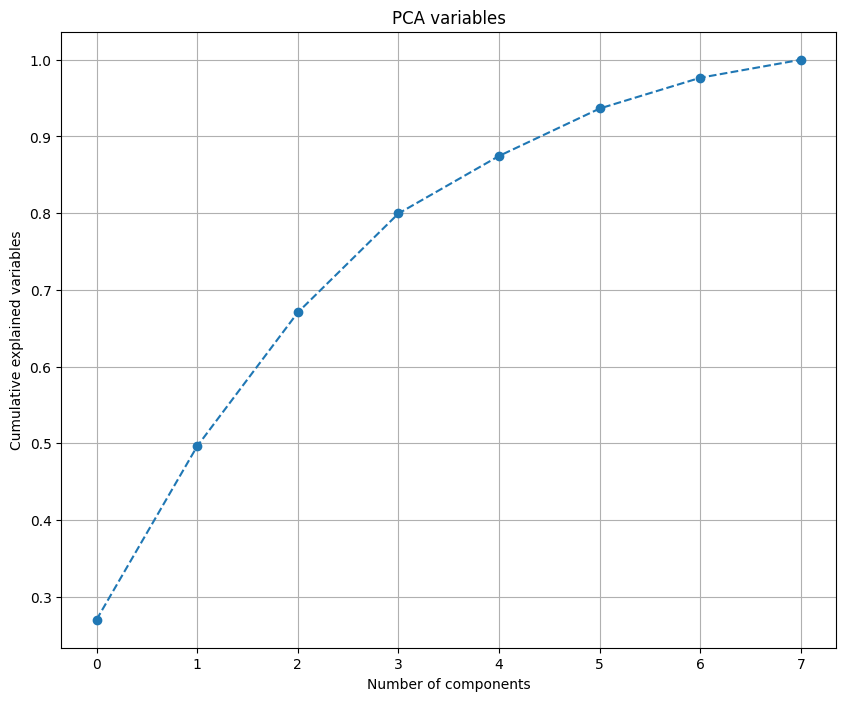

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(pca.explained_variance_ratio_.cumsum(), marker = 'o',linestyle = '--')
plt.grid()
plt.title('PCA variables')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variables')

In [ ]:
# 6. Aplicación de PCA ---> considerando el análisis anterior se eligen 5 componentes
# esto debido a que con 5 se tiene un valor cercano al 90% de explicación de la variables
# Ademas, no se elevaría demasiado el costo computacional

pca = PCA(n_components = 5)
data_PCA_f = pca.fit_transform(data_Norm_wine)
print(pca.explained_variance_ratio_)

[0.2698883  0.22614025 0.17444254 0.1290528  0.07501966]


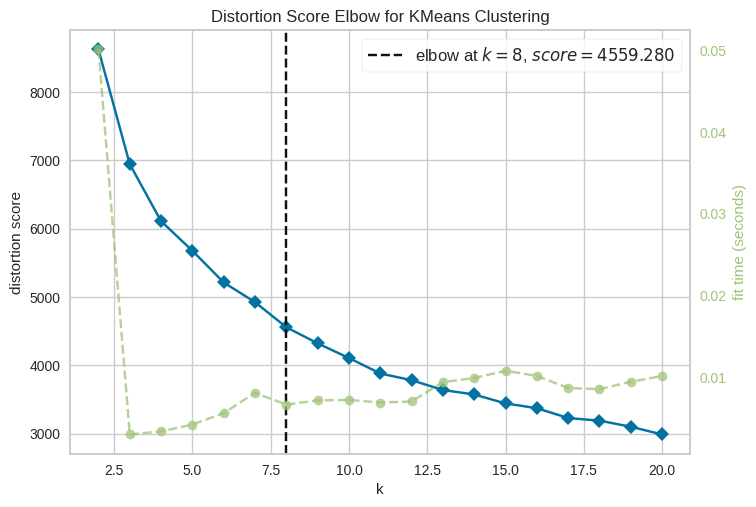

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# 7. Aplicacion del algoritmo KMEANS
from sklearn.cluster import KMeans
from sklearn import metrics
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import sklearn
import yellowbrick

vzr = KElbowVisualizer(KMeans(), k=(2, 21))
vzr.fit(data_PCA_f)
vzr.poof()

In [ ]:
clusters = 8
metric_k = []
for cluster in range(2, clusters):
  cl_kmeans = KMeans(n_clusters = cluster, random_state = 42).fit(data_PCA_f)
  metric_k.append(np.round(metrics.silhouette_score(data_PCA_f, cl_kmeans.labels_), 3))

print(f"Silhouette Coefficient: {metric_k}")

Silhouette Coefficient: [np.float64(0.184), np.float64(0.239), np.float64(0.23), np.float64(0.215), np.float64(0.206), np.float64(0.21)]


In [ ]:
# con el análisis anterior el mejor valor de la metrica Solhouette es para 3 clusters
cl_kmeans = KMeans(n_clusters = 3, random_state = 42).fit(data_PCA_f)
print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(data_PCA_f, cl_kmeans.labels_))

Silhouette Coefficient: 0.239


In [ ]:
silhouette_values_KM = metrics.silhouette_samples(data_PCA_f, cl_kmeans.labels_)

means_lst1 = []
for label in range(3):
    means_lst1.append(round(silhouette_values_KM[cl_kmeans.labels_ == label].mean(), 2))
print (means_lst1)

[np.float64(0.23), np.float64(0.27), np.float64(0.21)]


In [ ]:
import collections
print(collections.Counter(cl_kmeans.labels_))

Counter({np.int32(1): 661, np.int32(0): 495, np.int32(2): 443})


In [ ]:
# ----------------------------------------------------------
# interpretacion de los resultados de KMEANS con el dataset original
# ----------------------------------------------------------
data_original = data_wine.copy()
data_original['Class'] = cl_kmeans.labels_

data_group1 = data_original.groupby(['Class']).agg(pd.Series.mean)
data_group1.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,alcohol
Class,,,,,,,,
0,9.822222,0.383293,0.470828,2.406566,0.080634,10.547475,28.092929,10.881751
1,7.270045,0.628956,0.110272,2.136157,0.078847,12.394100,33.397882,10.377685
2,8.103047,0.533386,0.287257,2.506095,0.085323,26.351016,83.783296,9.965839


<Axes: xlabel='citric acid', ylabel='residual sugar'>

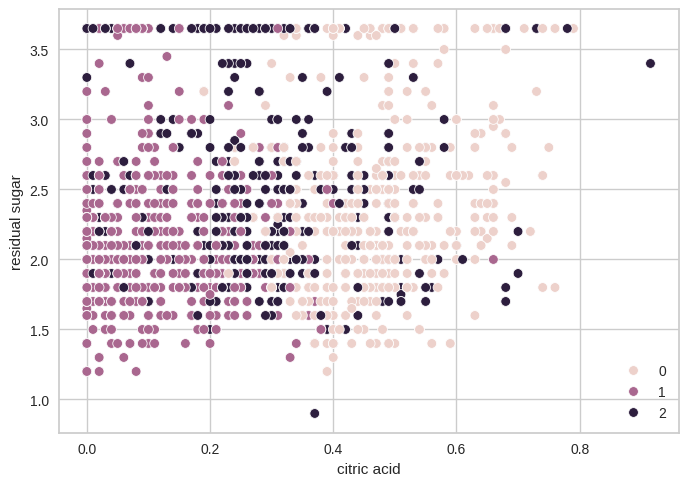

In [ ]:
sns.scatterplot(data= data_original, x= data_original.iloc[:, 2], y=data_original.iloc[:, 3], hue=cl_kmeans.labels_)

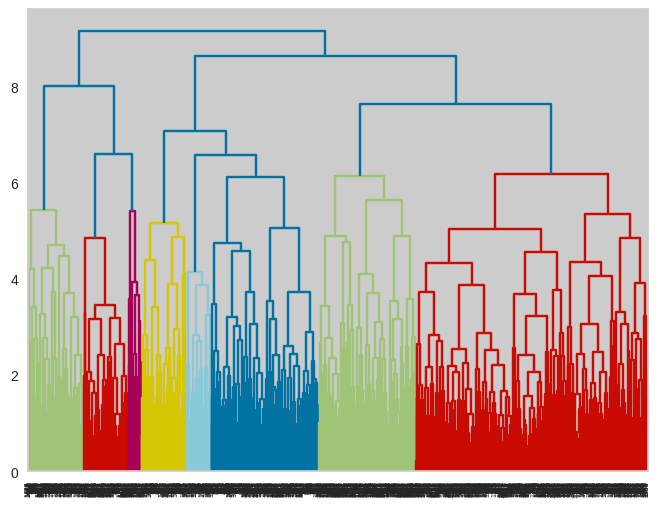

In [ ]:
# 6. Aplicación de Clustering Jerarquico ---> considerando el análisis PCA con 5 componentes
# esto debido a que con 5 se tiene un valor cercano al 90% de explicación de la variables
# Ademas, no se elevaría demasiado el costo computacional

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy
from sklearn import metrics

clusters = hierarchy.linkage(data_PCA_f, method="complete")
plt.figure(figsize=(8, 6))
dendrogram = hierarchy.dendrogram(clusters)

In [ ]:
clusters = 8
metric_jq = []
for cluster in range(2, clusters):
  cl_jq = AgglomerativeClustering(n_clusters=cluster, linkage="ward").fit(data_PCA_f)
  metric_jq.append(np.round(metrics.silhouette_score(data_PCA_f, cl_jq.labels_), 3))

print(f"Silhouette Coefficient: {metric_jq}")

Silhouette Coefficient: [np.float64(0.197), np.float64(0.179), np.float64(0.187), np.float64(0.178), np.float64(0.176), np.float64(0.174)]


In [ ]:
# con el análisis anterior el mejor valor de la metrica Solhouette es para 4 clusters
cl_jq = AgglomerativeClustering(n_clusters=4, linkage="ward").fit(data_PCA_f)
print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(data_PCA_f, cl_jq.labels_))

Silhouette Coefficient: 0.187


In [ ]:
print(collections.Counter(cl_jq.labels_))

Counter({np.int64(2): 544, np.int64(1): 442, np.int64(0): 410, np.int64(3): 203})


In [ ]:
# ----------------------------------------------------------
# interpretacion de los resultados de JERARQUICO con el dataset original
# ----------------------------------------------------------
data_original2 = data_wine.copy()
data_original2['Class'] = cl_jq.labels_

data_group2 = data_original2.groupby(['Class']).agg(pd.Series.mean)
data_group2.head(4)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,alcohol
Class,,,,,,,,
0,7.689512,0.552037,0.233293,2.427683,0.080641,27.374390,81.339024,10.172520
1,10.118665,0.404265,0.483020,2.463575,0.086231,11.798643,34.540724,10.453544
2,7.566544,0.645404,0.122279,2.196783,0.083316,10.993566,32.538603,9.997672
3,7.466995,0.421872,0.283448,2.138670,0.065660,13.142857,33.403941,11.975616


<Axes: xlabel='citric acid', ylabel='residual sugar'>

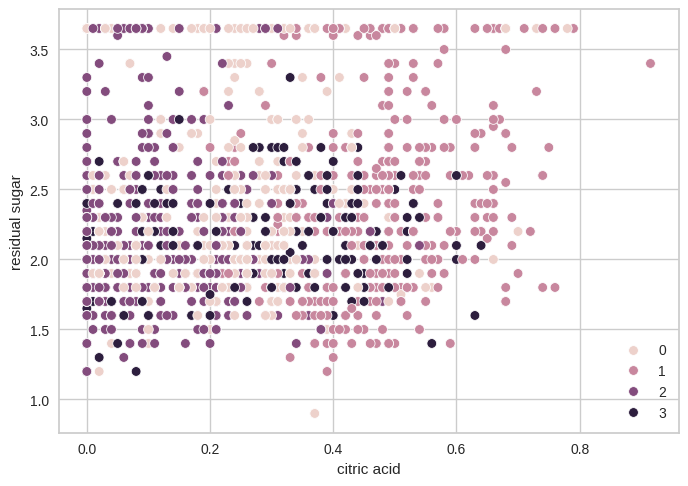

In [ ]:
sns.scatterplot(data= data_original2, x= data_original2.iloc[:, 2], y=data_original2.iloc[:, 3], hue=cl_jq.labels_)

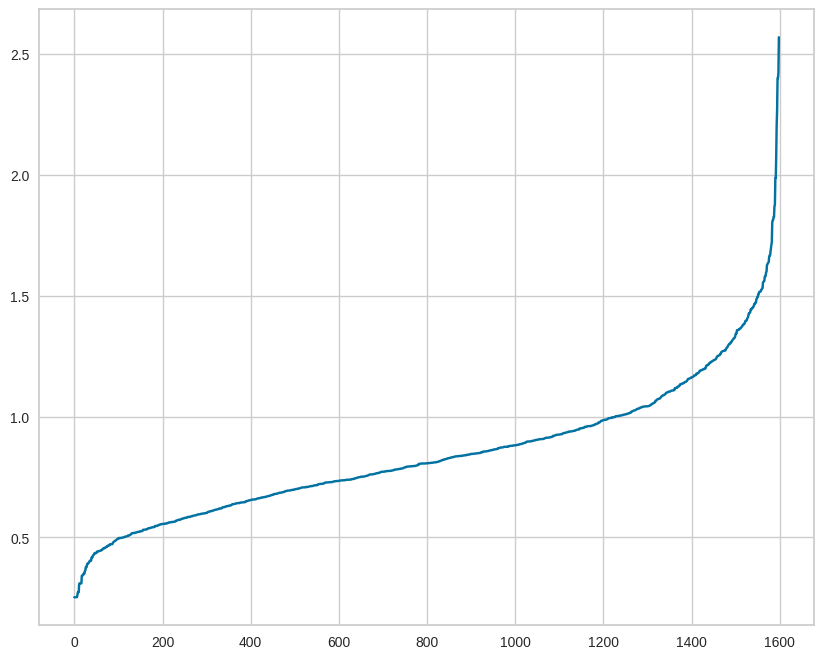

In [ ]:
# 7. Aplicación de DBSCAN ---> considerando el análisis PCA con 5 componentes
# esto debido a que con 5 se tiene un valor cercano al 90% de explicación de la variables
# Ademas, no se elevaría demasiado el costo computacional

from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=15).fit(data_PCA_f)
distances, indices = nn.kneighbors(data_PCA_f)

distances = np.sort(distances, axis=0)
distances = distances[:,4]
plt.figure(figsize=(10,8))
plt.plot(distances)
plt.grid('on')

In [ ]:
from sklearn.cluster import DBSCAN

cl_DBSCAN = DBSCAN(eps=1.9, min_samples=15).fit(data_PCA_f)

print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(data_PCA_f, cl_DBSCAN.labels_))
print (collections.Counter(cl_DBSCAN.labels_))

Silhouette Coefficient: 0.355
Counter({np.int64(0): 1594, np.int64(-1): 5})


In [ ]:
silhouette_values_DBSCAN = metrics.silhouette_samples(data_PCA_f, cl_DBSCAN.labels_)

means_lst2 = []
for label in range(2):
   means_lst2.append(round(silhouette_values_DBSCAN[cl_DBSCAN.labels_ == label].mean(), 2))
print (means_lst2)

[np.float64(0.36), np.float64(nan)]


/tmp/ipykernel_728/1262146770.py:5: RuntimeWarning: Mean of empty slice.
  means_lst2.append(round(silhouette_values_DBSCAN[cl_DBSCAN.labels_ == label].mean(), 2))
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(collections.Counter(cl_DBSCAN.labels_))

Counter({np.int64(0): 1594, np.int64(-1): 5})


In [ ]:
# ----------------------------------------------------------
# interpretacion de los resultados de DBSCAN con el dataset original
# ----------------------------------------------------------
data_original3 = data_wine.copy()
data_original3['Class'] = cl_DBSCAN.labels_

data_group3 = data_original2.groupby(['Class']).agg(pd.Series.mean)
data_group3.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,alcohol
Class,,,,,,,,
0,7.689512,0.552037,0.233293,2.427683,0.080641,27.374390,81.339024,10.172520
1,10.118665,0.404265,0.483020,2.463575,0.086231,11.798643,34.540724,10.453544
2,7.566544,0.645404,0.122279,2.196783,0.083316,10.993566,32.538603,9.997672
3,7.466995,0.421872,0.283448,2.138670,0.065660,13.142857,33.403941,11.975616


<Axes: xlabel='residual sugar', ylabel='chlorides'>

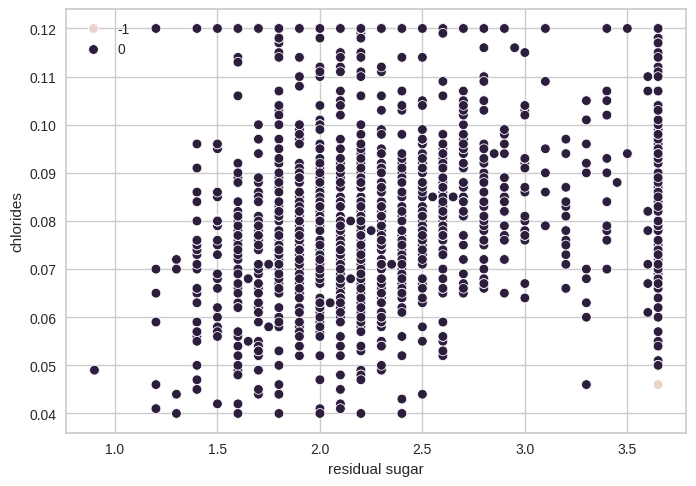

In [ ]:
sns.scatterplot(data= data_original3, x= data_original3.iloc[:, 3], y=data_original3.iloc[:, 4], hue=cl_DBSCAN.labels_)